In [1]:
# Cell 1: Import libraries and load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('data/clean_reviews.csv')
df['review_date'] = pd.to_datetime(df['review_date'])

print("✓ Data loaded!")
print("Shape:", df.shape)

✓ Data loaded!
Shape: (1111, 11)


In [2]:
# Cell 2: Understand TextBlob before applying it to all reviews
# Always test on small examples first!

print("=" * 55)
print("UNDERSTANDING TEXTBLOB")
print("=" * 55)

test_reviews = [
    "I absolutely love this app! It changed my life completely.",
    "Terrible app. Crashes every single day. Total waste of money.",
    "It is okay. Nothing special about it.",
    "Great concept but the subscription price is way too high!",
    "Cannot believe they removed the free features. Disgusting."
]

for review in test_reviews:
    blob = TextBlob(review)
    polarity     = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    print(f"\nReview : {review}")
    print(f"Polarity     : {polarity:.2f}  (-1=very negative, +1=very positive)")
    print(f"Subjectivity : {subjectivity:.2f}  (0=factual, 1=very opinionated)")

    if polarity > 0.1:
        print("Verdict : POSITIVE 😊")
    elif polarity < -0.1:
        print("Verdict : NEGATIVE 😠")
    else:
        print("Verdict : NEUTRAL 😐")
    print("-" * 55)

UNDERSTANDING TEXTBLOB

Review : I absolutely love this app! It changed my life completely.
Polarity     : 0.36  (-1=very negative, +1=very positive)
Subjectivity : 0.50  (0=factual, 1=very opinionated)
Verdict : POSITIVE 😊
-------------------------------------------------------

Review : Terrible app. Crashes every single day. Total waste of money.
Polarity     : -0.32  (-1=very negative, +1=very positive)
Subjectivity : 0.49  (0=factual, 1=very opinionated)
Verdict : NEGATIVE 😠
-------------------------------------------------------

Review : It is okay. Nothing special about it.
Polarity     : 0.43  (-1=very negative, +1=very positive)
Subjectivity : 0.54  (0=factual, 1=very opinionated)
Verdict : POSITIVE 😊
-------------------------------------------------------

Review : Great concept but the subscription price is way too high!
Polarity     : 0.50  (-1=very negative, +1=very positive)
Subjectivity : 0.65  (0=factual, 1=very opinionated)
Verdict : POSITIVE 😊
-----------------------

In [3]:
# Cell 3: Understand VADER before applying it
# VADER is better for reviews than TextBlob

print("=" * 55)
print("UNDERSTANDING VADER")
print("=" * 55)

analyzer = SentimentIntensityAnalyzer()

test_reviews = [
    "I absolutely love this app! It changed my life completely.",
    "Terrible app. Crashes every single day. Total waste of money.",
    "It is okay. Nothing special about it.",
    "Great concept but the subscription price is way too high!",
    "Cannot believe they removed the free features. Disgusting."
]

for review in test_reviews:
    scores = analyzer.polarity_scores(review)

    print(f"\nReview   : {review}")
    print(f"Negative : {scores['neg']:.2f}")
    print(f"Neutral  : {scores['neu']:.2f}")
    print(f"Positive : {scores['pos']:.2f}")
    print(f"Compound : {scores['compound']:.2f}  ← THIS is our main score")

    if scores['compound'] >= 0.05:
        print("Verdict  : POSITIVE 😊")
    elif scores['compound'] <= -0.05:
        print("Verdict  : NEGATIVE 😠")
    else:
        print("Verdict  : NEUTRAL 😐")
    print("-" * 55)

print("\n")
print("WHY VADER IS BETTER FOR REVIEWS:")
print("→ Understands CAPS like TERRIBLE vs terrible")
print("→ Understands !!! like amazing!!! vs amazing")
print("→ Built specifically for social/review text")
print("→ Compound score is one clean number we can use")


UNDERSTANDING VADER

Review   : I absolutely love this app! It changed my life completely.
Negative : 0.00
Neutral  : 0.65
Positive : 0.35
Compound : 0.70  ← THIS is our main score
Verdict  : POSITIVE 😊
-------------------------------------------------------

Review   : Terrible app. Crashes every single day. Total waste of money.
Negative : 0.44
Neutral  : 0.56
Positive : 0.00
Compound : -0.73  ← THIS is our main score
Verdict  : NEGATIVE 😠
-------------------------------------------------------

Review   : It is okay. Nothing special about it.
Negative : 0.25
Neutral  : 0.55
Positive : 0.21
Compound : -0.09  ← THIS is our main score
Verdict  : NEGATIVE 😠
-------------------------------------------------------

Review   : Great concept but the subscription price is way too high!
Negative : 0.00
Neutral  : 0.76
Positive : 0.24
Compound : 0.43  ← THIS is our main score
Verdict  : POSITIVE 😊
-------------------------------------------------------

Review   : Cannot believe they removed t

In [4]:
# Cell 4: Apply both sentiment tools to all reviews
# This may take 1-2 minutes

print("Applying sentiment analysis to all reviews...")
print("Please wait...\n")

analyzer = SentimentIntensityAnalyzer()

# --- TextBlob functions ---
def get_tb_polarity(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return TextBlob(text).sentiment.polarity

def get_tb_subjectivity(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return TextBlob(text).sentiment.subjectivity

# --- VADER functions ---
def get_vader_compound(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return analyzer.polarity_scores(text)['compound']

def get_vader_pos(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return analyzer.polarity_scores(text)['pos']

def get_vader_neg(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return analyzer.polarity_scores(text)['neg']


# Apply to every review
df['tb_polarity']     = df['review_text_clean'].apply(get_tb_polarity)
df['tb_subjectivity'] = df['review_text_clean'].apply(get_tb_subjectivity)
print("✓ TextBlob done")

df['vader_compound']  = df['review_text_clean'].apply(get_vader_compound)
df['vader_pos']       = df['review_text_clean'].apply(get_vader_pos)
df['vader_neg']       = df['review_text_clean'].apply(get_vader_neg)
print("✓ VADER done")

print("\nSample of scores:")
print(df[['review_text_clean', 'rating',
          'tb_polarity', 'vader_compound']].head(5))

Applying sentiment analysis to all reviews...
Please wait...

✓ TextBlob done
✓ VADER done

Sample of scores:
                                   review_text_clean  rating  tb_polarity  \
0  hello habitika! you are the best! i want to he...       5     0.033333   
1  how can i silence justin in the app? he won't ...       3     0.000000   
2  good idea but there aren't enough customizable...       4     0.350000   
3                               wow world of wonders       5     0.100000   
4                          all ok, my fault for rtfm       5     0.500000   

   vader_compound  
0          0.8650  
1          0.0000  
2          0.2382  
3          0.5859  
4         -0.4019  


In [5]:
# Cell 5: Convert scores into labels (Positive/Neutral/Negative)

def label_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['vader_compound'].apply(label_sentiment)

print("=== SENTIMENT DISTRIBUTION ===")
counts = df['sentiment_label'].value_counts()
total  = len(df)

for label, count in counts.items():
    pct = count / total * 100
    print(f"{label:10} : {count:4} reviews ({pct:.1f}%)")

print("\n=== VALIDATION CHECK ===")
print("Do sentiment scores match star ratings?")
print("(They should — this tells us our tool is working)")
print()
print(df.groupby('rating')['vader_compound'].mean().round(3))
print()
print("1 star should be NEGATIVE (below 0)")
print("5 star should be POSITIVE (above 0)")

=== SENTIMENT DISTRIBUTION ===
Positive   :  617 reviews (55.5%)
Negative   :  377 reviews (33.9%)
Neutral    :  117 reviews (10.5%)

=== VALIDATION CHECK ===
Do sentiment scores match star ratings?
(They should — this tells us our tool is working)

rating
1   -0.193
2    0.014
3    0.175
4    0.490
5    0.647
Name: vader_compound, dtype: float64

1 star should be NEGATIVE (below 0)
5 star should be POSITIVE (above 0)


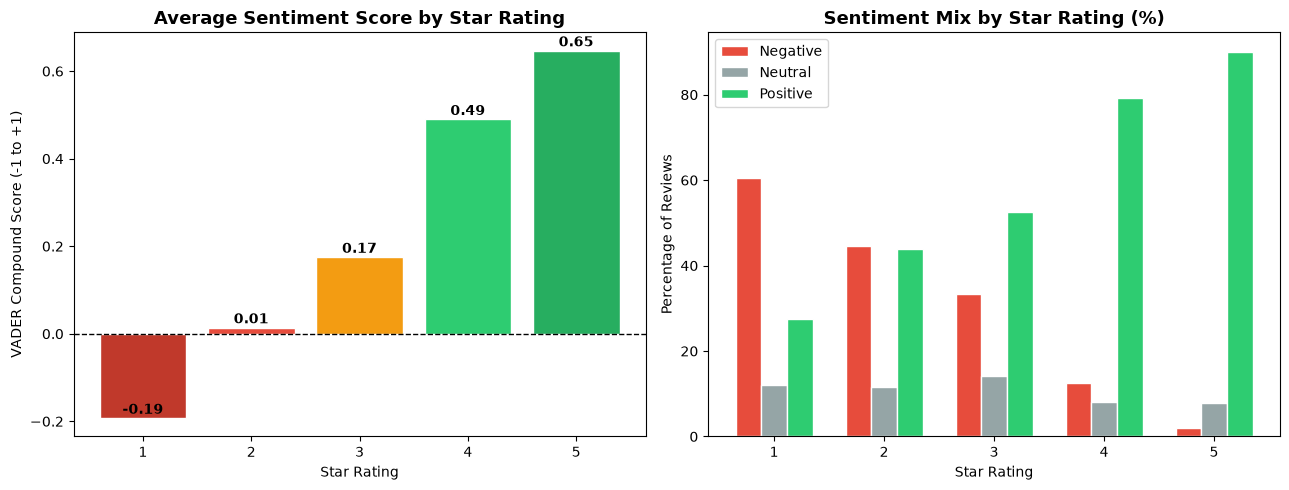

✓ Chart saved!


In [6]:
# Cell 6: Visualize sentiment scores vs actual star ratings

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left chart: Average VADER score per star rating ---
avg_sentiment = df.groupby('rating')['vader_compound'].mean()

bar_colors = ['#c0392b', '#e74c3c', '#f39c12', '#2ecc71', '#27ae60']
bars = axes[0].bar(
    avg_sentiment.index,
    avg_sentiment.values,
    color=bar_colors,
    edgecolor='white'
)

axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Average Sentiment Score by Star Rating',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('VADER Compound Score (-1 to +1)')

for bar, score in zip(bars, avg_sentiment.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{score:.2f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

# --- Right chart: Sentiment label mix per star rating ---
sentiment_mix = df.groupby(
    ['rating', 'sentiment_label']
).size().unstack(fill_value=0)

sentiment_pct = sentiment_mix.div(
    sentiment_mix.sum(axis=1), axis=0
) * 100

sentiment_pct.plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    edgecolor='white',
    width=0.7
)

axes[1].set_title('Sentiment Mix by Star Rating (%)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Percentage of Reviews')
axes[1].legend(loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('outputs/charts/06_sentiment_vs_rating.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

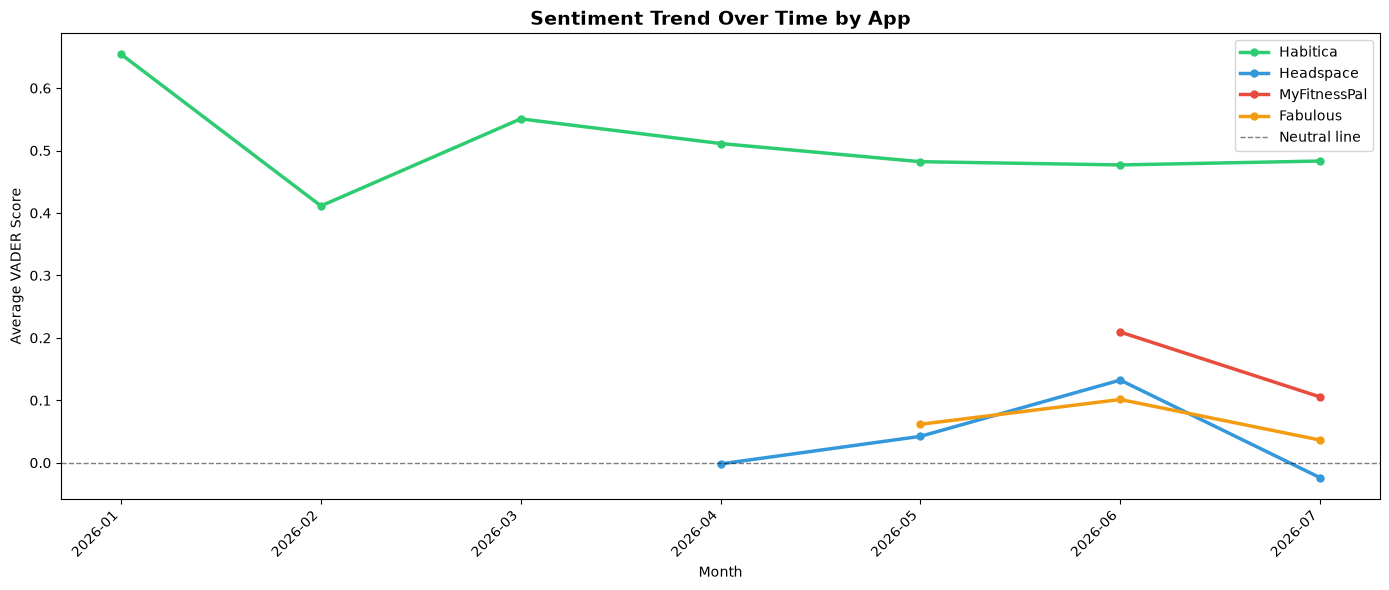

✓ Chart saved!


In [7]:
# Cell 7: How has sentiment changed over time per app?

df['year_month'] = df['review_date'].dt.to_period('M')

monthly = df.groupby(
    ['year_month', 'app_name']
)['vader_compound'].mean().reset_index()

monthly['year_month'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

app_colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, app in enumerate(df['app_name'].unique()):
    app_data = monthly[monthly['app_name'] == app]
    ax.plot(
        app_data['year_month'],
        app_data['vader_compound'],
        label=app,
        linewidth=2.5,
        marker='o',
        markersize=5,
        color=app_colors[i % len(app_colors)]
    )

ax.axhline(y=0, color='black', linestyle='--',
           linewidth=1, alpha=0.5, label='Neutral line')
ax.set_title('Sentiment Trend Over Time by App',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average VADER Score')
ax.legend(loc='best')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/charts/07_sentiment_over_time.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

In [8]:
# Cell 8: Save data with sentiment scores added

import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/sentiment_reviews.csv', index=False)

print("✓ Sentiment data saved!")
print("\n=== FINAL SENTIMENT SUMMARY ===")
print(f"Total reviews analysed  : {len(df)}")
print(f"Positive reviews        : {(df['sentiment_label']=='Positive').sum()}")
print(f"Neutral reviews         : {(df['sentiment_label']=='Neutral').sum()}")
print(f"Negative reviews        : {(df['sentiment_label']=='Negative').sum()}")
print(f"\nCorrelation between VADER score and star rating:")
corr = df['vader_compound'].corr(df['rating'])
print(f"  {corr:.3f}")
print()
if corr > 0.5:
    print("✓ Strong correlation — our sentiment tool is working well!")
elif corr > 0.3:
    print("✓ Moderate correlation — sentiment tool is working")
else:
    print("⚠ Weak correlation — worth investigating")

✓ Sentiment data saved!

=== FINAL SENTIMENT SUMMARY ===
Total reviews analysed  : 1111
Positive reviews        : 617
Neutral reviews         : 117
Negative reviews        : 377

Correlation between VADER score and star rating:
  0.617

✓ Strong correlation — our sentiment tool is working well!
